In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import openflash as of
from scipy.special import hankel1e 
import capytaine as cpt


In [38]:
num_subdivs=10
truncastion_order = 50

r1 = 2.5/2 # bottom radius [m]
r2 = 8.4/2 # top radius [m]

d1 = 14.45 # draft [m]
d2 = 14.45-7.32 # vertical distance to bottom of slant [m]
d3 = 14.45-7.32-5.08 # vertical distance to top of slant [m]

rho=1000
g=9.81
omega_sweep = np.linspace(0.4,1.5,10)
h = 100            # Water Depth (m)
heaving_list = True 



In [39]:
def CorPower_geom(r1,r2,d1,d2,d3,num_subdivs):

    d_list = np.linspace(d2,d3,num_subdivs)
    a_list = np.linspace(r1,r2,num_subdivs)

    d_list[0] = d1

    return d_list, a_list



In [40]:
d_list, a_list = CorPower_geom(r1,r2,d1,d2,d3,num_subdivs)
num_regions = len(d_list)
NMK = [truncastion_order] * (num_regions+1)

Text(0.5, 1.0, 'CorPower WEC profile')

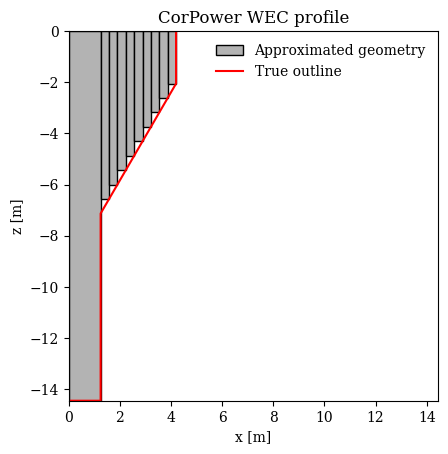

In [41]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
fig, ax = plt.subplots()
for i, (a, d) in enumerate(zip(a_list,d_list)):
    if i==0:
        a_in=0 
        ax.fill([a_in,a,a,a_in],[-d,-d,0,0], color=[0.7,0.7,0.7], edgecolor='black', label='Approximated geometry')       
    else:
        a_in=a_list[i-1]
        ax.fill([a_in,a,a,a_in],[-d,-d,0,0], color=[0.7,0.7,0.7], edgecolor='black')
ax.plot([0,r1,r1,r2,r2],[-d1,-d1,-d2,-d3,0],color="red",label="True outline")
ax.set_aspect('equal')
ax.legend(loc='best', frameon=False)
ax.set_xlim([0, -np.min(-d_list)])
ax.set_ylim([np.min(-d_list),0])
ax.set_xlabel("x [m]")
ax.set_ylabel("z [m]")
ax.set_title("CorPower WEC profile")

In [42]:
# m0 = of.multi_equations.wavenumber(omega_sweep[j], h)

bodies_sweep = []

# Single Body
body = of.SteppedBody(
    a=np.array(a_list),
    d=np.array(d_list),
    slant_angle= np.zeros_like(a_list),
    heaving=heaving_list
)

bodies_sweep.append(body)

# 2. Create arrangement
arrangement_sweep = of.ConcentricBodyGroup(bodies_sweep)

# 3. Create geometry
geometry_sweep = of.BasicRegionGeometry(
    body_arrangement=arrangement_sweep,
    h=h,
    NMK=NMK
)

# 4. Create the MEEMProblem instance
problem = of.MEEMProblem(geometry_sweep)

# 5. Set the frequencies for the sweep
problem.set_frequencies(omega_sweep)

# 6. Initialize a new MEEM Engine for this problem
engine = of.MEEMEngine(problem_list=[problem])

results = engine.run_and_store_results(0)
data_set = results.get_results()
# print(data_set.added_mass)# for omega in omega_sweep:
#     m0 = of.multi_equations.wavenumber(omega, h)
#     X = engine.solve_linear_system_multi(problem, m0)
#     coeffs = engine.compute_hydrodynamic_coefficients(problem, X, m0)




results.export_to_netcdf("my_simulation_output.nc")

Hydrodynamic coefficients stored in xarray dataset.
Potentials stored in xarray dataset (batched across frequencies/modes).


In [43]:
data_set.added_mass.values

array([[[120286.38244982]],

       [[117380.35209374]],

       [[109813.64918634]],

       [[100389.88606451]],

       [[ 90710.48787193]],

       [[ 81829.25134979]],

       [[ 74424.68141535]],

       [[ 68790.17023513]],

       [[ 64920.2800569 ]],

       [[ 62619.15172185]]])

In [44]:
# hydrostatics

def compute_hydrostatics(a_list, d_list, rho, g):
    hydrostatic_stiffness = 0
    mass = 0

    for i in range(len(a_list)):    
        if i==0:
            area_i = np.pi*a_list[i]**2
        else:
            area_i = np.pi*(a_list[i]**2-a_list[i-1]**2)
        volume_i = area_i * d_list[i]

        hydrostatic_stiffness += rho * g * area_i
        mass += rho * volume_i 

    return hydrostatic_stiffness, mass 


hydrostatic_stiffness, mass = compute_hydrostatics(a_list, d_list, rho, g)
print(mass) 
print(hydrostatic_stiffness) 

265650.78129563207
543647.582155468
